In [1]:
# Import Python Standard Library dependencies
import json
import math
import os

# Import utility functions
from cjm_pytorch_utils.core import set_seed

# Import the distinctipy module
from distinctipy import distinctipy

# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Import numpy
import numpy as np

# Import the pandas package
import pandas as pd

# Set options for Pandas DataFrame display
pd.set_option('max_colwidth', None)  # Do not truncate the contents of cells in the DataFrame
pd.set_option('display.max_rows', None)  # Display all rows in the DataFrame
pd.set_option('display.max_columns', None)  # Display all columns in the DataFrame

# Import PIL for image manipulation
from PIL import Image

# Import PyTorch dependencies
import torch
import torch.nn.functional as F
import torchvision
torchvision.disable_beta_transforms_warning()

# Import Mask R-CNN
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import cv2

# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed for generating random numbers in PyTorch, NumPy, and Python's random module.
seed = 1234
set_seed(seed)

/home/jamesp/Desktop/maskrcnn_from_scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import numpy as np

img_files = os.listdir('data/images_wac')
labels = {}

for img_file in img_files:
    img_name = img_file.split('.')[0]
    
    # Load the corresponding label
    label_file = f'data/labels_wac/{img_name}.txt'
    with open(label_file, 'r') as f:
        lines = f.readlines()[1:]  # Skip header line if present
        gt_ellipses = []
        gt_bboxes = []
        
        for line in lines:
            data = line.strip().split(',')
            x_centre, y_centre, semi_major_axis, semi_minor_axis, angle = map(float, data)
            
            # Store the ellipse parameters
            gt_ellipses.append([x_centre, y_centre, semi_major_axis, semi_minor_axis, angle])

            # Convert angle to radians
            theta = np.radians(angle)
            
            # The correct approach: compute bounding box directly from the rotated ellipse
            # The bounding box of a rotated ellipse can be calculated by:
            # width = 2 * sqrt((a*cos(theta))^2 + (b*sin(theta))^2)
            # height = 2 * sqrt((a*sin(theta))^2 + (b*cos(theta))^2)
            # where a is semi-major axis, b is semi-minor axis
            
            width = 2 * np.sqrt((semi_major_axis * np.cos(theta))**2 + 
                               (semi_minor_axis * np.sin(theta))**2)
            
            height = 2 * np.sqrt((semi_major_axis * np.sin(theta))**2 + 
                                (semi_minor_axis * np.cos(theta))**2)
            
            # Calculate the bounding box coordinates
            x_min = x_centre - width/2
            x_max = x_centre + width/2
            y_min = y_centre - height/2
            y_max = y_centre + height/2
            
            gt_bboxes.append([x_min, y_min, x_max, y_max])
        
        labels[img_name] = {
            'ellipses': gt_ellipses,
            'bboxes': gt_bboxes
        }
        
labels

{'M103052117ME_1': {'ellipses': [[222.0, 463.0, 315.0, 311.0, 49.5737],
   [240.0, 272.0, 40.0, 38.0, 34.8635],
   [465.0, 299.0, 48.0, 45.0, 109.351],
   [744.0, 263.0, 52.0, 50.0, 97.5727],
   [712.0, 330.0, 49.0, 48.0, 161.435],
   [728.0, 685.0, 60.0, 58.0, 58.9417],
   [807.0, 547.0, 100.0, 93.0, 8.62137],
   [599.0, 985.0, 58.0, 56.0, 8.24653],
   [22.0, 858.0, 40.0, 36.0, 72.1677],
   [263.0, 995.0, 25.0, 24.0, 96.8236],
   [253.0, 935.0, 45.0, 41.0, 54.7148],
   [572.0, 920.0, 20.0, 19.0, 124.416],
   [826.0, 1020.0, 29.0, 27.0, 137.341],
   [825.0, 928.0, 27.0, 25.0, 78.3912],
   [715.0, 921.0, 26.0, 26.0, 117.148],
   [623.0, 797.0, 35.0, 31.0, 67.8515],
   [754.0, 856.0, 20.0, 18.0, 122.506],
   [841.0, 788.0, 24.0, 23.0, 160.191],
   [823.0, 795.0, 20.0, 17.0, 150.982],
   [800.0, 891.0, 31.0, 30.0, 174.264],
   [909.0, 857.0, 18.0, 17.0, 109.283],
   [805.0, 768.0, 17.0, 15.0, 10.1514],
   [1001.0, 891.0, 25.0, 24.0, 28.5357],
   [644.0, 738.0, 19.0, 18.0, 66.7721],
   [50

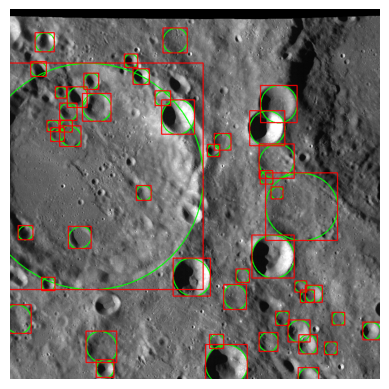

In [3]:
import cv2
import matplotlib.pyplot as plt

# Load image
image_dir = 'data/images_wac/M103052117ME_1.png'
image = cv2.imread(image_dir)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get labels
image_label = labels['M103052117ME_1']
ellipses = image_label['ellipses']
bboxes = image_label['bboxes']

# Draw ellipses
for ellipse in ellipses:
    x_centre, y_centre, semi_major_axis, semi_minor_axis, angle = ellipse
    cv2.ellipse(image, 
                (int(x_centre), int(y_centre)),  # Center
                (int(semi_major_axis), int(semi_minor_axis)),  # Axes
                angle,  # Rotation angle
                0, 360,  # StartAngle and EndAngle (full ellipse)
                (0, 255, 0),  # Green color
                2)  # Thickness

# Draw bounding boxes
for bbox in bboxes:
    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(image, 
                  (int(x_min), int(y_min)), 
                  (int(x_max), int(y_max)), 
                  (255, 0, 0),  # Red color
                  2)  # Thickness

# Display image
plt.imshow(image)
plt.axis('off')
plt.show()


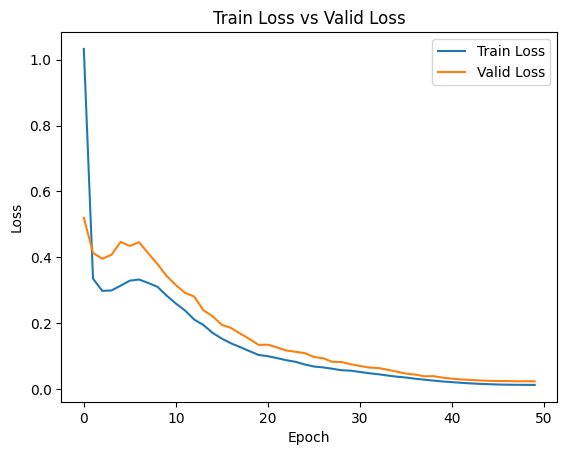

In [4]:
import json

losses = []

train_hist_dir = 'pytorch-mask-r-cnn-instance-segmentation/2025-03-29_11-11-57/training_metadata.json'
with open(train_hist_dir, 'r') as file:
    data_epochs = json.load(file)

    for data_epoch in data_epochs:
        train_loss = data_epoch['train_loss']
        valid_loss = data_epoch['valid_loss']
        epoch = data_epoch['epoch']
        losses.append((epoch, train_loss, valid_loss))

# Extract the data for plotting
epochs = [epoch for epoch, _, _ in losses]
train_losses = [train_loss for _, train_loss, _ in losses]
valid_losses = [valid_loss for _, _, valid_loss in losses]

# Plot the train_loss and valid_loss
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, valid_losses, label='Valid Loss')

# Add labels and title to the plot
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train Loss vs Valid Loss')

# Add legend to the plot
plt.legend()

# Show the plot
plt.show()


In [5]:
device = 'cuda:1'
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   
# device = torch.device('cpu')
dtype = torch.float32

class_names = ['background']+['crater']

model = maskrcnn_resnet50_fpn_v2(weights='DEFAULT')

# Get the number of input features for the classifier
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

# Get the numbner of output channels for the Mask Predictor
dim_reduced = model.roi_heads.mask_predictor.conv5_mask.out_channels

# Replace the box predictor
model.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_features_box, num_classes=len(class_names))

# Replace the mask predictor
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_channels=in_features_mask, dim_reduced=dim_reduced, num_classes=len(class_names))

# Set the model's device and data type
model.to(device=device, dtype=dtype)

# Add attributes to store the device and model name for later reference
model.device = device
model.name = 'maskrcnn_resnet50_fpn_v2'


# Load the weights of the model
weights_path = "pytorch-mask-r-cnn-instance-segmentation/2025-03-20_11-32-50_fda/maskrcnn_resnet50_fpn_v2.pth"
model.load_state_dict(torch.load(weights_path))

model.eval()

/home/jamesp/Desktop/maskrcnn_from_scratch/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

In [6]:
from cjm_pil_utils.core import resize_img
import torchvision.transforms.v2  as transforms
from cjm_pytorch_utils.core import move_data_to_device
from torchvision.tv_tensors import BoundingBoxes, Mask


test_images = {} #{'id': [image_with_ellipses: np.array, [gt_bboxs:list[list], pred_bboxes:list[list]]}

train_sz = 1024

min_img_scale = 1


for image_name in tqdm(labels.keys()):
    bounding_boxes = []
    ellipses_ = []

    img_dir = f"data/images_wac/{image_name}.png"
    image = cv2.imread(img_dir)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    input_img = Image.fromarray(image)
    img_labels = labels[image_name]
    
    # Get the ground truth ellipses and bounding boxes
    ellipses_.append(img_labels['ellipses'])
    bounding_boxes.append(img_labels['bboxes'])
        
    input_tensor = transforms.Compose([transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)])(input_img)[None].to(device)
    
    # Make a prediction with the model
    with torch.no_grad():
        model_output = model(input_tensor)

    # Set the confidence threshold
    threshold = 0.5

    # Move model output to the CPU
    model_output = move_data_to_device(model_output, 'cpu')

    # Filter the output based on the confidence threshold
    scores_mask = model_output[0]['scores'] > threshold

    # Scale the predicted bounding boxes
    pred_bboxes = BoundingBoxes(model_output[0]['boxes'][scores_mask]*min_img_scale, format='xyxy', canvas_size=input_img.size[::-1])

    # Scale and stack the predicted segmentation masks
    pred_masks = F.interpolate(model_output[0]['masks'][scores_mask], size=input_img.size[::-1])
    
    if pred_masks.size(0) > 0:
        pred_masks = torch.concat([Mask(torch.where(mask >= threshold, 1, 0), dtype=torch.bool) for mask in pred_masks])
    else:
        pred_masks = torch.empty((0, 1, train_sz, train_sz), dtype=torch.bool)


    input_img_np = np.array(resize_img(input_img, target_sz=train_sz, divisor=1))

    #draw GT
    gt_ellipses = []
    for label in img_labels['ellipses']:
        x_centre, y_centre, semi_major_axis, semi_minor_axis, angle = label
        gt_ellipses.append([x_centre, y_centre, semi_major_axis, semi_minor_axis, angle])
        cv2.ellipse(input_img_np, (int(x_centre), int(y_centre)), (int(semi_major_axis), int(semi_minor_axis)), angle=angle, startAngle=0, endAngle=360, color=(0, 255, 0), thickness=2)
    
    # draw Pred
    pred_ellipses = []
    for mask in pred_masks:
        # Find contours of the mask
        contours, _ = cv2.findContours(mask.numpy().astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours)>1:
            contours = [max(contours, key=cv2.contourArea)]
            
        if contours:
        # Fit ellipse to the contour
            if len(contours[0]) >=5:
                ellipse_params = cv2.fitEllipse(contours[0]) #((x,y), (2majorAxis, 2minorAxis), angle(degree))

                param = []
                param.append(ellipse_params[0][0])
                param.append(ellipse_params[0][1])
                param.append(ellipse_params[1][0]/2)
                param.append(ellipse_params[1][1]/2)
                param.append(ellipse_params[2])
                pred_ellipses.append(param)

                ellipse_area = np.pi * (ellipse_params[1][0] / 2) * (ellipse_params[1][1] / 2)
                ellipse_peri = 2 * np.pi * np.sqrt(ellipse_area/np.pi)
                contour_peri = cv2.arcLength(contours[0], closed=True)

                T = ellipse_peri/contour_peri if ellipse_peri <= contour_peri else contour_peri/ellipse_peri
                if T >= 0.5: #ellipse_index_threshhold
                # Plot the contour
                    cv2.ellipse(input_img_np, (int(param[0]), int(param[1])), (int(param[2]), int(param[3])), angle=param[4], startAngle=0, endAngle=360, color=(255, 0, 0), thickness=2)

    ellipses_.append(pred_ellipses)

    pred_bboxes = BoundingBoxes(model_output[0]['boxes'][scores_mask]*min_img_scale, format='xyxy', canvas_size=input_img.size[::-1])
    pred_bboxes =  pred_bboxes.round(decimals=3).numpy().tolist()
    bounding_boxes.append(pred_bboxes)

    test_images[image_name] = [input_img_np, bounding_boxes, ellipses_]

 32%|███▏      | 115/358 [00:11<00:21, 11.07it/s]

100%|██████████| 358/358 [00:33<00:00, 10.73it/s]


In [7]:
def calculate_iou(box1, box2):
        # Calculate the intersection area
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])
        intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)

        # Calculate the union area
        box1_area = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
        box2_area = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)
        union_area = box1_area + box2_area - intersection_area

        # Calculate the IoU
        iou = intersection_area / union_area
        return iou
    
TP = 0
FP = 0
FN = 0

threshold = 0.5
for id, content in test_images.items():
    bounding_boxes = content[1]
    ground_truth_boxes = bounding_boxes[0]
    predicted_boxes = bounding_boxes[1]

    # Initialize arrays to track whether a ground truth or prediction has been matched
    gt_matched = [False] * len(ground_truth_boxes)
    pred_matched = [False] * len(predicted_boxes)

    # Iterate over each predicted bounding box
    for pred_idx, pred_box in enumerate(predicted_boxes):
        max_iou = 0
        max_iou_idx = -1

        # Iterate over each ground truth bounding box to find the one with maximum IOU
        for gt_idx, gt_box in enumerate(ground_truth_boxes):
            iou = calculate_iou(pred_box, gt_box)
            if iou > max_iou:
                max_iou = iou
                max_iou_idx = gt_idx

        # If the maximum IOU is above a threshold, consider it a true positive
        if max_iou >= threshold:
            TP += 1
            gt_matched[max_iou_idx] = True
            pred_matched[pred_idx] = True
        else:
            FP += 1

    # Any ground truth boxes not matched to predictions are false negatives
    FN += sum(not matched for matched in gt_matched)

# Calculate false negatives for predictions not matched to any ground truth
FN += sum(not matched for matched in pred_matched)

# Calculate accuracy, precision, and recall
accuracy = (TP) / (TP + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Accuracy: 0.002082567683449712
Precision: 0.15454545454545454
Recall: 0.0021065675340768276
F1 Score: 0.004156479217603913


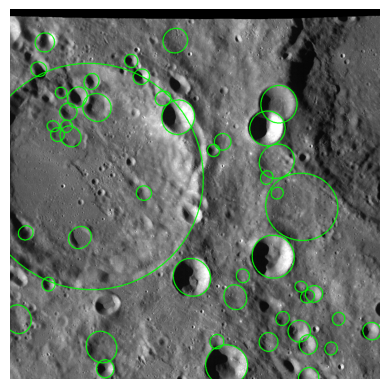

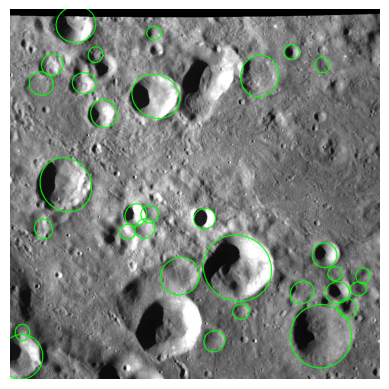

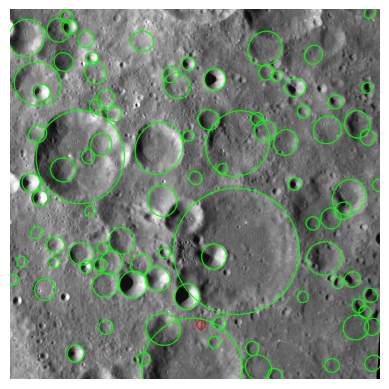

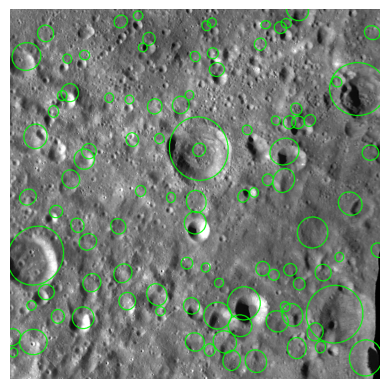

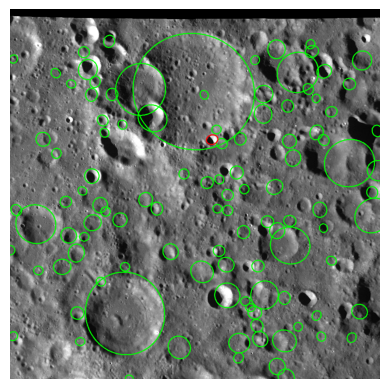

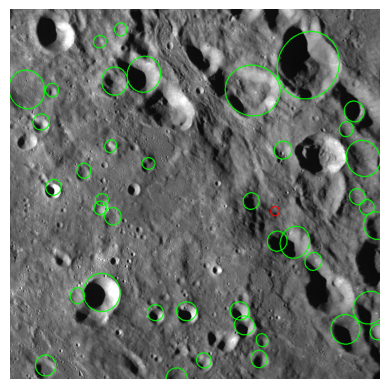

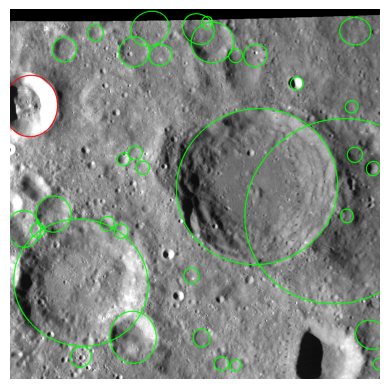

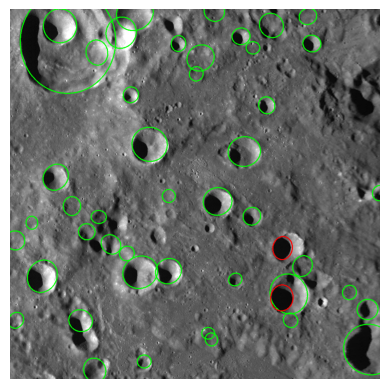

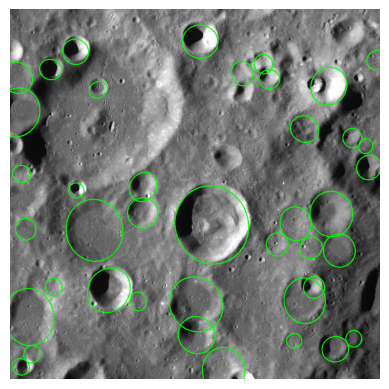

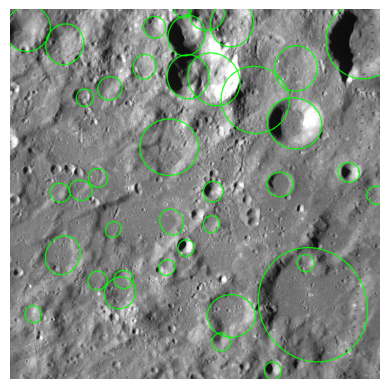

In [8]:
for id, content in list(test_images.items())[:10]:
    img = content[0]
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    